In [1]:
# ── Standard Libraries ──
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Machine Learning ──
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, precision_recall_curve,
                              average_precision_score, f1_score,
                              accuracy_score, precision_score, recall_score)
from sklearn.utils import resample

# ── Ensemble Algorithm ──
from xgboost import XGBClassifier
import xgboost as xgb

# ── Deep Learning ──
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense, Dropout, BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# ── Set Style ──
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"XGBoost version: {xgb.__version__}")


✅ All libraries imported successfully!
TensorFlow version: 2.20.0
XGBoost version: 3.2.0


In [2]:
# ── Load Dataset ──
df = pd.read_csv('/content/creditcard.csv')

print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Total Transactions : {len(df):,}")
print(f"Total Features     : {df.shape[1]}")
print(f"Legitimate (0)     : {(df['Class'] == 0).sum():,}")
print(f"Fraudulent (1)     : {(df['Class'] == 1).sum():,}")
print(f"Fraud Percentage   : {(df['Class'].sum() / len(df) * 100):.3f}%")
print("=" * 50)


DATASET OVERVIEW
Total Transactions : 284,807
Total Features     : 31
Legitimate (0)     : 284,315
Fraudulent (1)     : 492
Fraud Percentage   : 0.173%


In [3]:
# ── First Look at Data ──
print("First 5 rows of dataset:")
df.head()


First 5 rows of dataset:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# ── Check Missing Values ──
missing = df.isnull().sum()
print("Missing Values:", missing.sum())
print("✅ No missing values!" if missing.sum() == 0 else "⚠️ Missing values found!")

# ── Data Types ──
print("\nData Types:")
print(df.dtypes.value_counts())


Missing Values: 0
✅ No missing values!

Data Types:
float64    30
int64       1
Name: count, dtype: int64


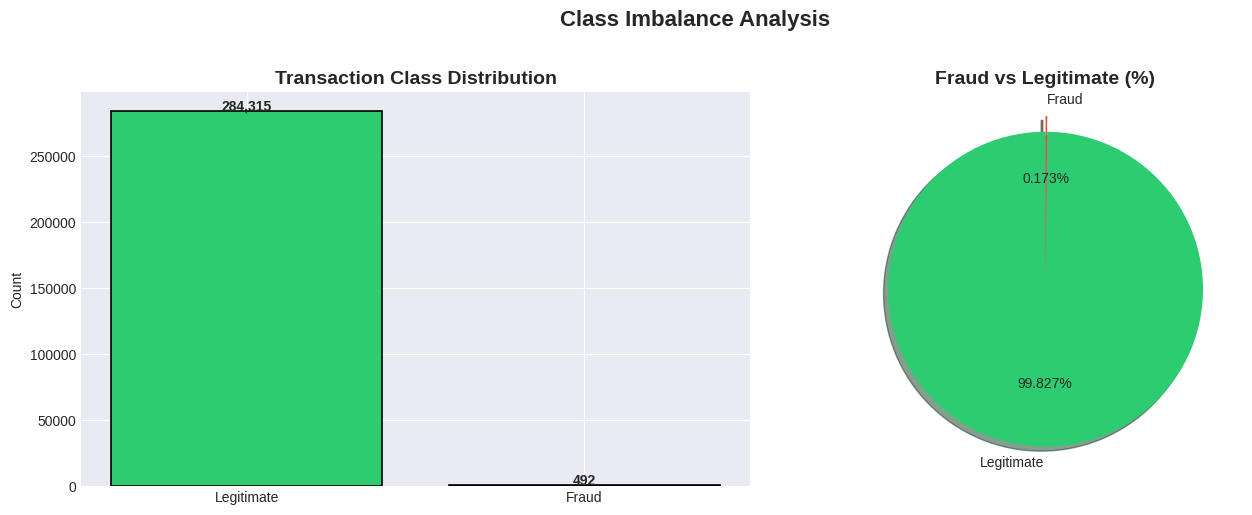

📊 Plot 1: Class distribution saved!


In [5]:
# ── PLOT 1: Class Distribution (Imbalance) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count Plot
class_counts = df['Class'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Legitimate', 'Fraud'], class_counts.values, color=colors, edgecolor='black', linewidth=1.2)
axes[0].set_title('Transaction Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Pie Chart
axes[1].pie(class_counts.values, labels=['Legitimate', 'Fraud'],
            colors=colors, autopct='%1.3f%%', startangle=90,
            explode=(0, 0.1), shadow=True)
axes[1].set_title('Fraud vs Legitimate (%)', fontsize=14, fontweight='bold')

plt.suptitle('Class Imbalance Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Plot 1: Class distribution saved!")


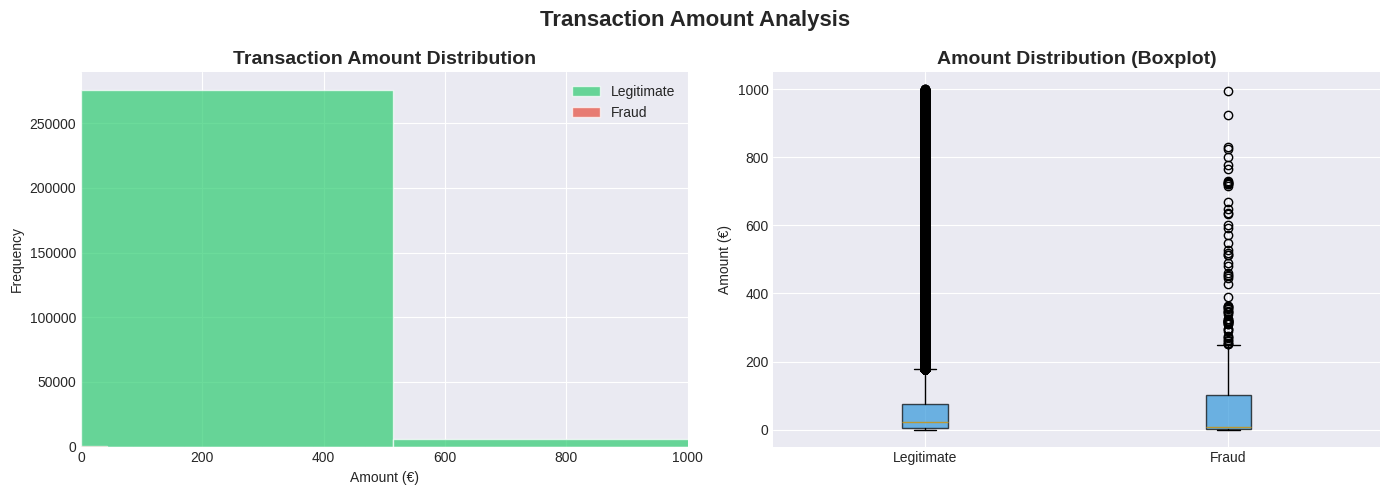

📊 Plot 2: Amount distribution saved!


In [6]:
# ── PLOT 2: Transaction Amount Distribution ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fraud = df[df['Class'] == 1]['Amount']
legit = df[df['Class'] == 0]['Amount']

axes[0].hist(legit, bins=50, color='#2ecc71', alpha=0.7, label='Legitimate', edgecolor='white')
axes[0].hist(fraud, bins=50, color='#e74c3c', alpha=0.7, label='Fraud', edgecolor='white')
axes[0].set_title('Transaction Amount Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Amount (€)')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].set_xlim(0, 1000)

# Box Plot
df_plot = df[['Amount', 'Class']].copy()
df_plot['Type'] = df_plot['Class'].map({0: 'Legitimate', 1: 'Fraud'})
axes[1].boxplot([legit[legit < 1000], fraud[fraud < 1000]],
                labels=['Legitimate', 'Fraud'],
                patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.7))
axes[1].set_title('Amount Distribution (Boxplot)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Amount (€)')

plt.suptitle('Transaction Amount Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('plot2_amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Plot 2: Amount distribution saved!")


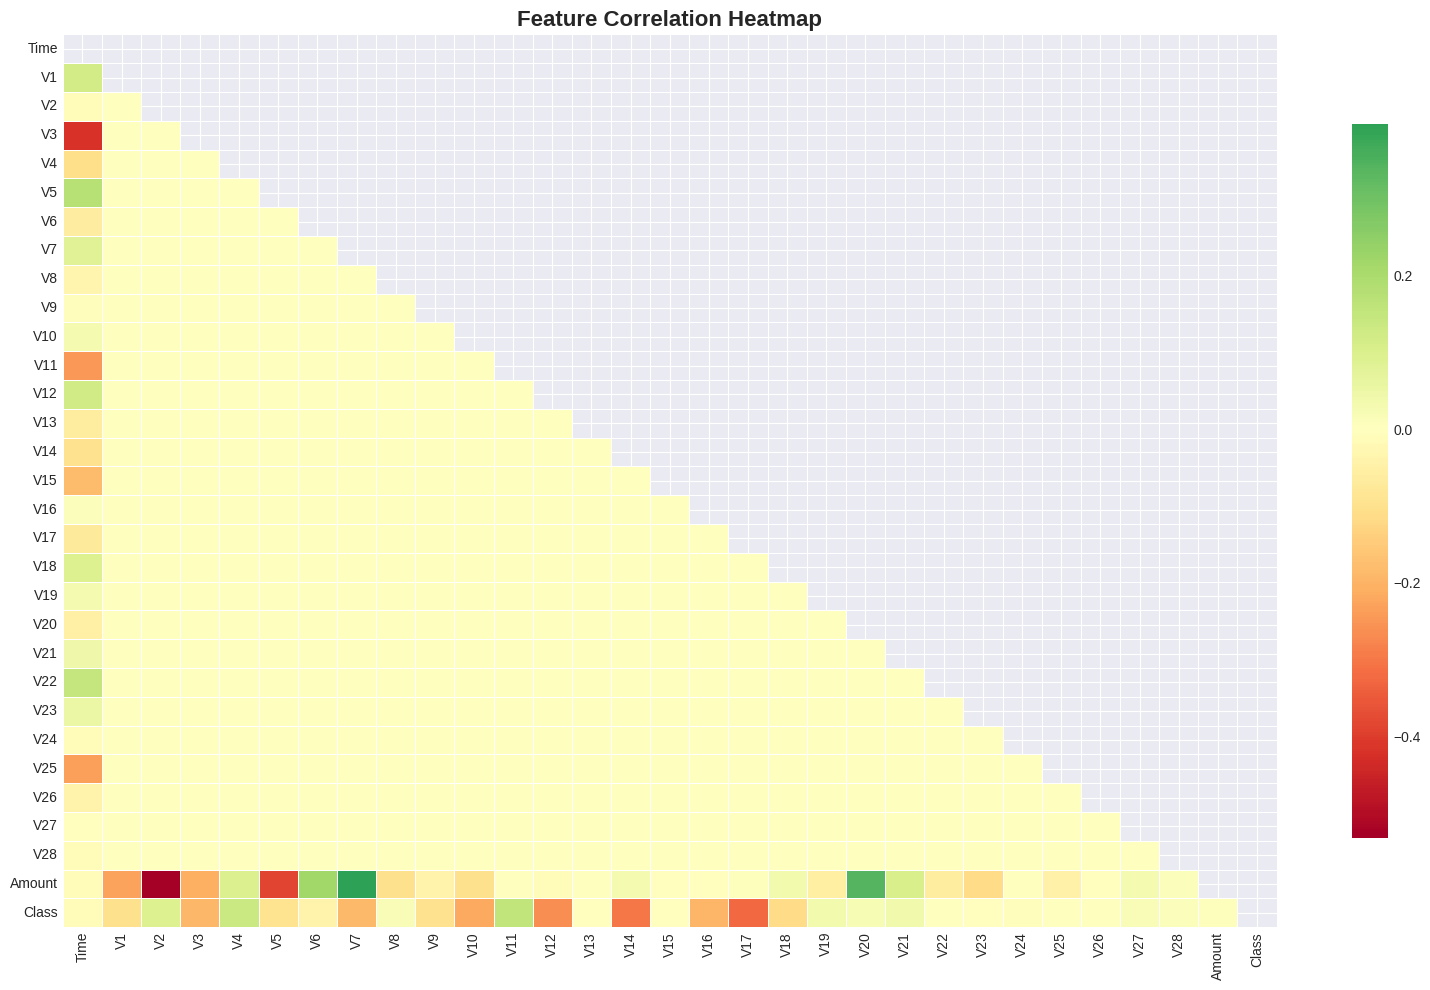

📊 Plot 3: Correlation heatmap saved!


In [7]:
# ── PLOT 3: Correlation Heatmap ──
plt.figure(figsize=(16, 10))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='RdYlGn',
            center=0, linewidths=0.5, fmt='.2f',
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('plot3_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Plot 3: Correlation heatmap saved!")


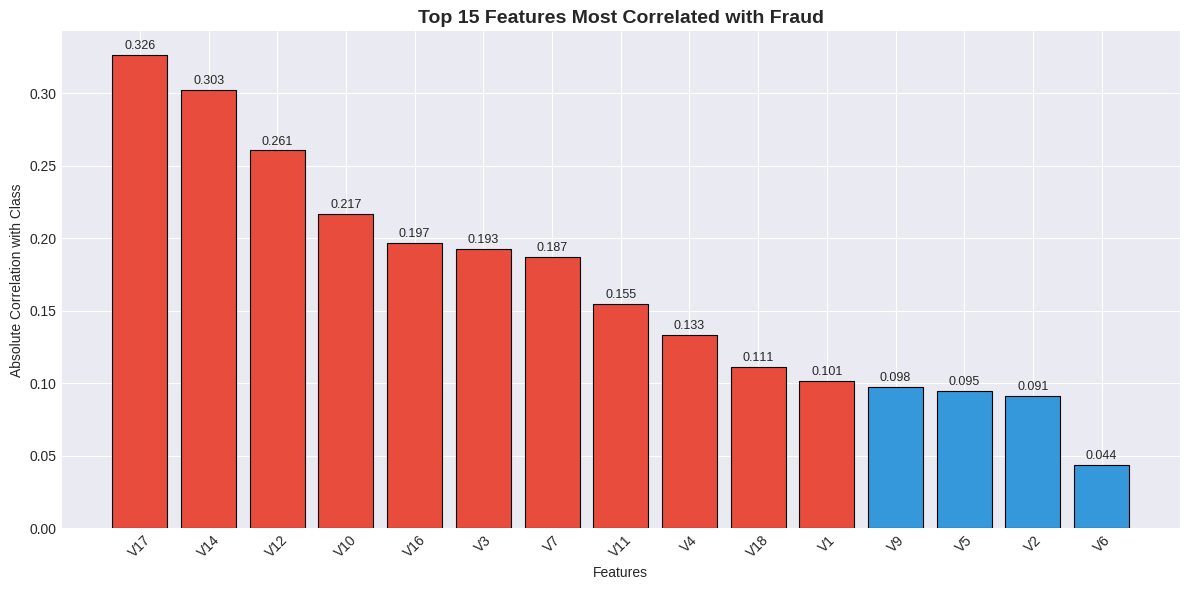

📊 Plot 4: Feature correlation with fraud saved!


In [8]:
# ── PLOT 4: Top Features Correlated with Fraud ──
fraud_corr = df.corr()['Class'].drop('Class').abs().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
colors_bar = ['#e74c3c' if x > 0.1 else '#3498db' for x in fraud_corr.values]
bars = plt.bar(fraud_corr.index, fraud_corr.values, color=colors_bar, edgecolor='black', linewidth=0.8)
plt.title('Top 15 Features Most Correlated with Fraud', fontsize=14, fontweight='bold')
plt.xlabel('Features')
plt.ylabel('Absolute Correlation with Class')
plt.xticks(rotation=45)
for bar, val in zip(bars, fraud_corr.values):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('plot4_feature_importance_corr.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Plot 4: Feature correlation with fraud saved!")


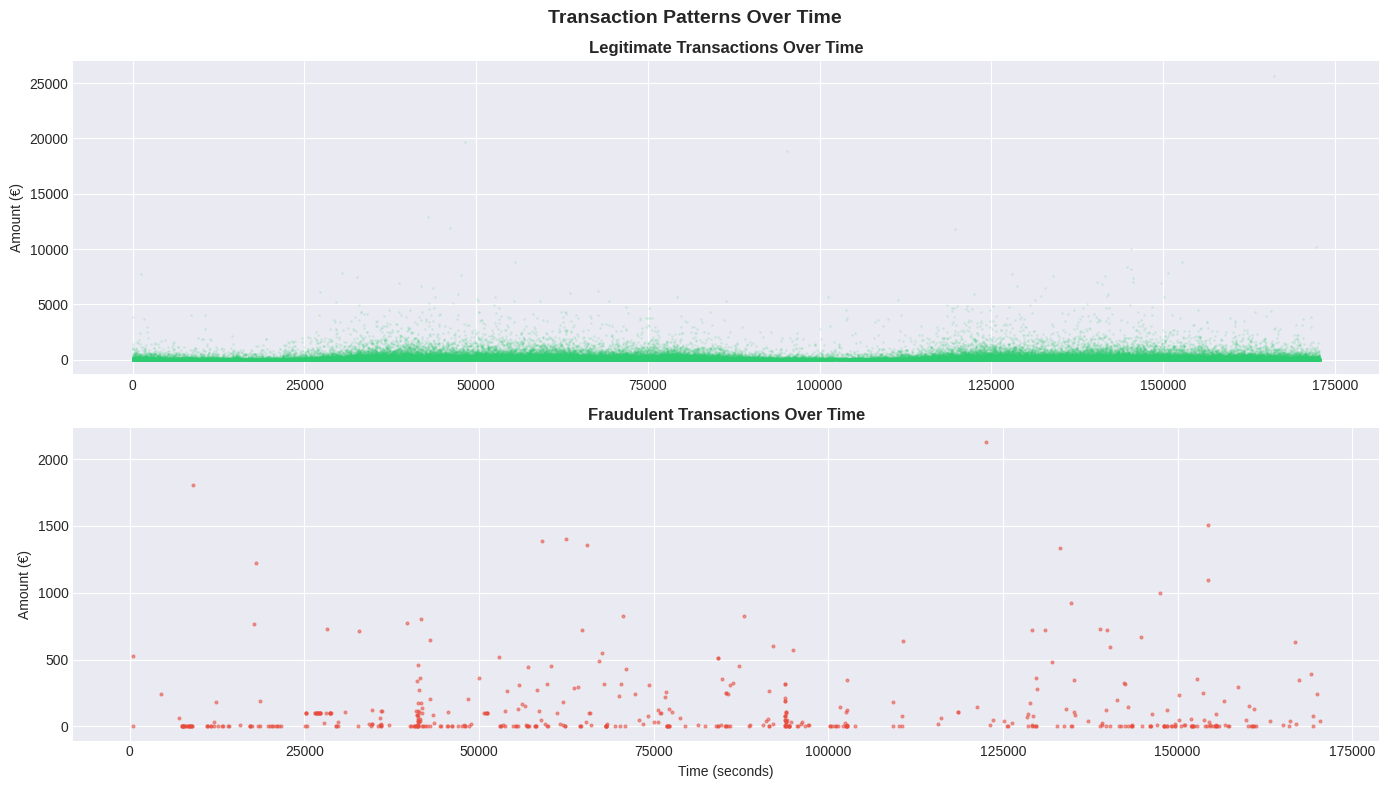

📊 Plot 5: Time pattern saved!


In [9]:
# ── PLOT 5: Time vs Fraud Pattern ──
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Legitimate
axes[0].plot(df[df['Class'] == 0]['Time'],
             df[df['Class'] == 0]['Amount'],
             '.', color='#2ecc71', alpha=0.1, markersize=2)
axes[0].set_title('Legitimate Transactions Over Time', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Amount (€)')

# Fraud
axes[1].plot(df[df['Class'] == 1]['Time'],
             df[df['Class'] == 1]['Amount'],
             '.', color='#e74c3c', alpha=0.5, markersize=4)
axes[1].set_title('Fraudulent Transactions Over Time', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Amount (€)')

plt.suptitle('Transaction Patterns Over Time', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot5_time_pattern.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Plot 5: Time pattern saved!")


In [10]:
# ── Step 1: Scale 'Amount' and 'Time' ──
scaler = StandardScaler()
df['Amount_Scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_Scaled']   = scaler.fit_transform(df[['Time']])

# Drop original columns
df_clean = df.drop(['Amount', 'Time'], axis=1)
print("✅ Amount and Time scaled!")

✅ Amount and Time scaled!


In [11]:
# ── Step 2: Handle Class Imbalance using Oversampling ──
# Separate classes
df_majority = df_clean[df_clean['Class'] == 0]
df_minority = df_clean[df_clean['Class'] == 1]

print(f"Before balancing — Legitimate: {len(df_majority):,} | Fraud: {len(df_minority):,}")

# Oversample fraud class
df_minority_upsampled = resample(df_minority,
                                  replace=True,
                                  n_samples=10000,
                                  random_state=42)

# Undersample majority class
df_majority_downsampled = resample(df_majority,
                                    replace=False,
                                    n_samples=10000,
                                    random_state=42)

# Combine
df_balanced = pd.concat([df_majority_downsampled, df_minority_upsampled])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"After balancing  — Legitimate: {(df_balanced['Class']==0).sum():,} | Fraud: {(df_balanced['Class']==1).sum():,}")
print("✅ Dataset balanced!")


Before balancing — Legitimate: 284,315 | Fraud: 492
After balancing  — Legitimate: 10,000 | Fraud: 10,000
✅ Dataset balanced!


In [12]:
# ── Step 3: Split Features and Target ──
X = df_balanced.drop('Class', axis=1)
y = df_balanced['Class']

# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training Set   : {X_train.shape}")
print(f"Testing Set    : {X_test.shape}")
print(f"Features       : {X_train.shape[1]}")
print("✅ Data split complete!")


Training Set   : (16000, 30)
Testing Set    : (4000, 30)
Features       : 30
✅ Data split complete!


In [13]:
# ── Build Deep Neural Network ──
def build_dnn(input_dim):
    model = Sequential([
        # Layer 1
        Dense(64, activation='relu', input_dim=input_dim),
        BatchNormalization(),
        Dropout(0.3),

        # Layer 2
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),

        # Layer 3
        Dense(16, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),

        # Output Layer
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

# Create model
dnn_model = build_dnn(X_train.shape[1])
dnn_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,057 (19.75 KB)

 Trainable params: 4,833 (18.88 KB)

 Non-trainable params: 224 (896.00 B)

In [14]:
# ── Train the DNN ──
early_stop = EarlyStopping(monitor='val_auc', patience=10,
                           restore_best_weights=True, mode='max')
lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=5, min_lr=1e-6)

print("Training Deep Neural Network...")
history = dnn_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, lr_reducer],
    verbose=1
)
print("\n✅ DNN Training Complete!")


Training Deep Neural Network...
Epoch 1/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9048 - auc: 0.9596 - loss: 0.2519 - val_accuracy: 0.9459 - val_auc: 0.9894 - val_loss: 0.1472 - learning_rate: 0.0010
Epoch 2/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9362 - auc: 0.9783 - loss: 0.1767 - val_accuracy: 0.9641 - val_auc: 0.9933 - val_loss: 0.1065 - learning_rate: 0.0010
Epoch 3/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9431 - auc: 0.9835 - loss: 0.1555 - val_accuracy: 0.9669 - val_auc: 0.9955 - val_loss: 0.0924 - learning_rate: 0.0010
Epoch 4/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9510 - auc: 0.9873 - loss: 0.1364 - val_accuracy: 0.9706 - val_auc: 0.9967 - val_loss: 0.0823 - learning_rate: 0.0010
Epoch 5/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9553 - auc: 0.9895 - loss: 0.1228 - val_accuracy: 0.9678 - val_auc: 0.9976 - val_loss: 0.0757 - learning_rate: 0.0010
Epoch 6/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s

In [15]:
# ── DNN Predictions ──
dnn_proba = dnn_model.predict(X_test).flatten()
dnn_pred  = (dnn_proba >= 0.5).astype(int)

print("=" * 50)
print("DEEP NEURAL NETWORK RESULTS")
print("=" * 50)
print(classification_report(y_test, dnn_pred, target_names=['Legitimate', 'Fraud']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, dnn_proba):.4f}")


125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
DEEP NEURAL NETWORK RESULTS
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      0.99      2000
       Fraud       0.99      1.00      0.99      2000

    accuracy                           0.99      4000
   macro avg       0.99      0.99      0.99      4000
weighted avg       0.99      0.99      0.99      4000

ROC-AUC Score: 0.9996


In [16]:
# ── Train XGBoost Model ──
print("Training XGBoost Ensemble Model...")

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

print("\n✅ XGBoost Training Complete!")


Training XGBoost Ensemble Model...
[0]	validation_0-auc:0.98127
[50]	validation_0-auc:0.99972
[100]	validation_0-auc:0.99978
[150]	validation_0-auc:0.99978
[199]	validation_0-auc:0.99978

✅ XGBoost Training Complete!


In [17]:
# ── XGBoost Predictions ──
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_pred  = xgb_model.predict(X_test)

print("=" * 50)
print("XGBOOST ENSEMBLE RESULTS")
print("=" * 50)
print(classification_report(y_test, xgb_pred, target_names=['Legitimate', 'Fraud']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, xgb_proba):.4f}")


XGBOOST ENSEMBLE RESULTS
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00      2000
       Fraud       1.00      1.00      1.00      2000

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000

ROC-AUC Score: 0.9998


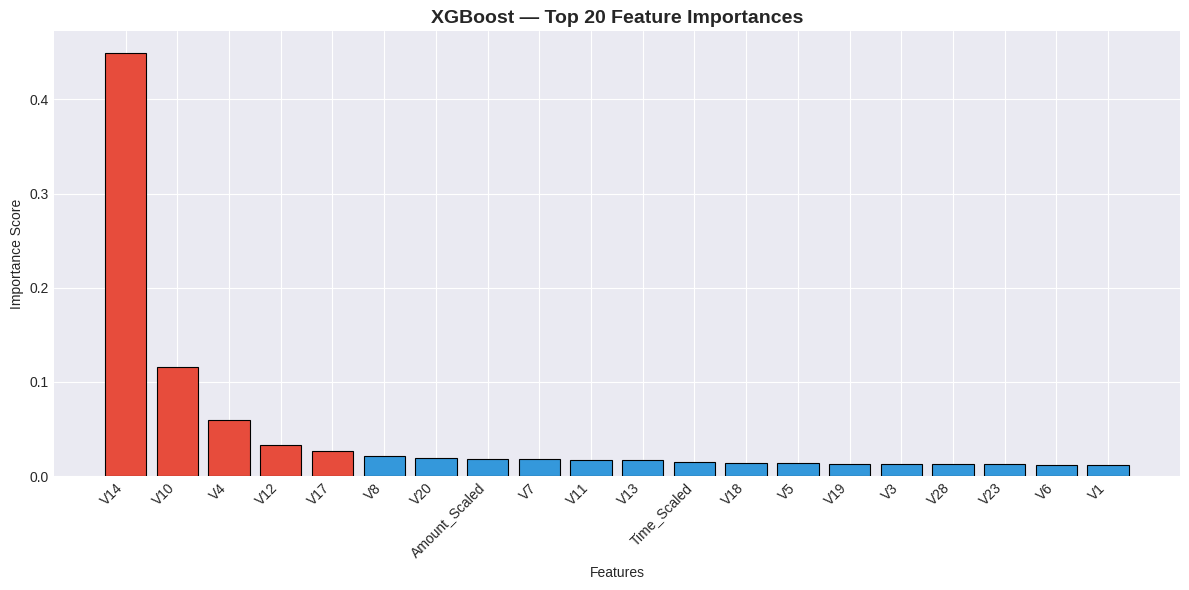

📊 Plot 7: XGBoost feature importance saved!


In [18]:
# ── XGBoost Feature Importance ──
plt.figure(figsize=(12, 6))
feat_imp = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(20)

colors_imp = ['#e74c3c' if i < 5 else '#3498db' for i in range(len(feat_imp))]
bars = plt.bar(feat_imp.index, feat_imp.values, color=colors_imp, edgecolor='black', linewidth=0.8)
plt.title('XGBoost — Top 20 Feature Importances', fontsize=14, fontweight='bold')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plot7_xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Plot 7: XGBoost feature importance saved!")


In [19]:
# ── Agent: Combine Both Models ──
# Weighted average (XGBoost slightly more weight as it's stronger on tabular data)
agent_proba = (0.4 * dnn_proba) + (0.6 * xgb_proba)
agent_pred  = (agent_proba >= 0.5).astype(int)

print("=" * 50)
print("🤖 FRAUD DETECTION AGENT — FINAL RESULTS")
print("=" * 50)
print(classification_report(agent_pred, y_test, target_names=['Legitimate', 'Fraud']))
print(f"ROC-AUC Score : {roc_auc_score(y_test, agent_proba):.4f}")
print(f"Accuracy      : {accuracy_score(y_test, agent_pred):.4f}")
print(f"Precision     : {precision_score(y_test, agent_pred):.4f}")
print(f"Recall        : {recall_score(y_test, agent_pred):.4f}")
print(f"F1-Score      : {f1_score(y_test, agent_pred):.4f}")


🤖 FRAUD DETECTION AGENT — FINAL RESULTS
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00      1993
       Fraud       1.00      1.00      1.00      2007

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000

ROC-AUC Score : 0.9997
Accuracy      : 0.9982
Precision     : 0.9965
Recall        : 1.0000
F1-Score      : 0.9983


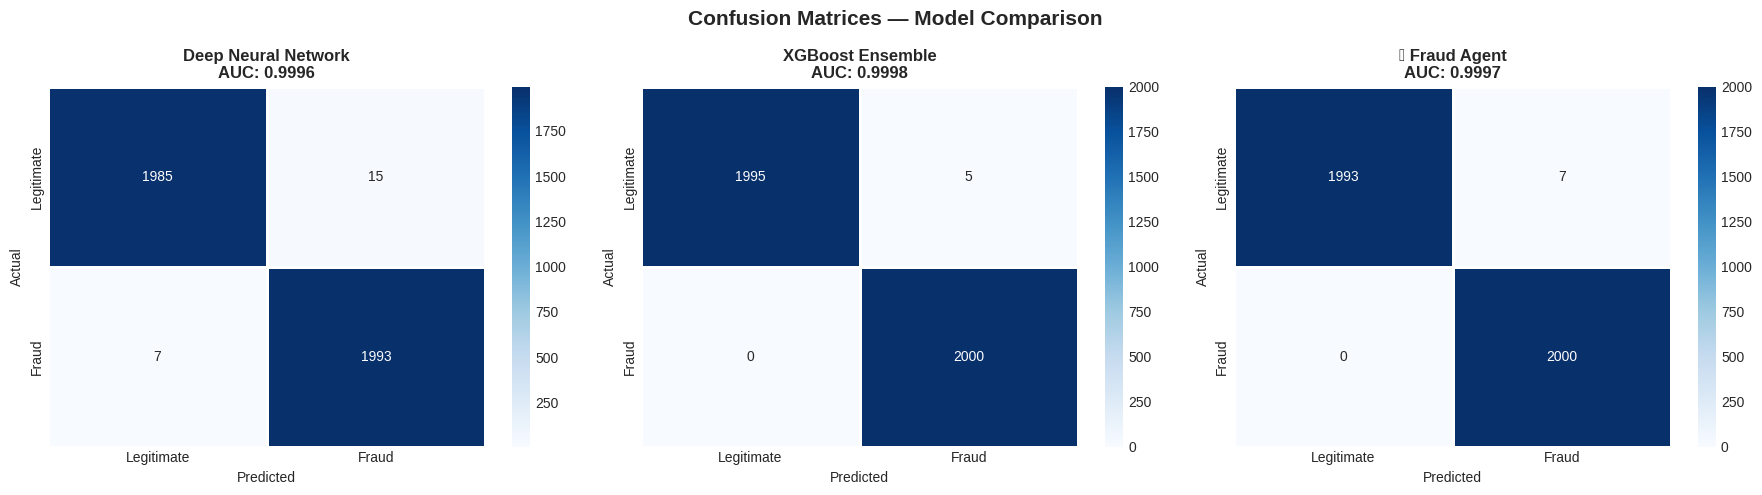

📊 Plot 8: Confusion matrices saved!


In [20]:
# ── PLOT 8: Confusion Matrices for All 3 ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_info = [
    (dnn_pred,   dnn_proba,   'Deep Neural Network', '#3498db'),
    (xgb_pred,   xgb_proba,   'XGBoost Ensemble',    '#2ecc71'),
    (agent_pred, agent_proba, '🤖 Fraud Agent',       '#e74c3c'),
]

for ax, (pred, proba, name, color) in zip(axes, models_info):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap='Blues', linewidths=1,
                xticklabels=['Legitimate', 'Fraud'],
                yticklabels=['Legitimate', 'Fraud'])
    ax.set_title(f'{name}\nAUC: {roc_auc_score(y_test, proba):.4f}',
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices — Model Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plot8_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Plot 8: Confusion matrices saved!")


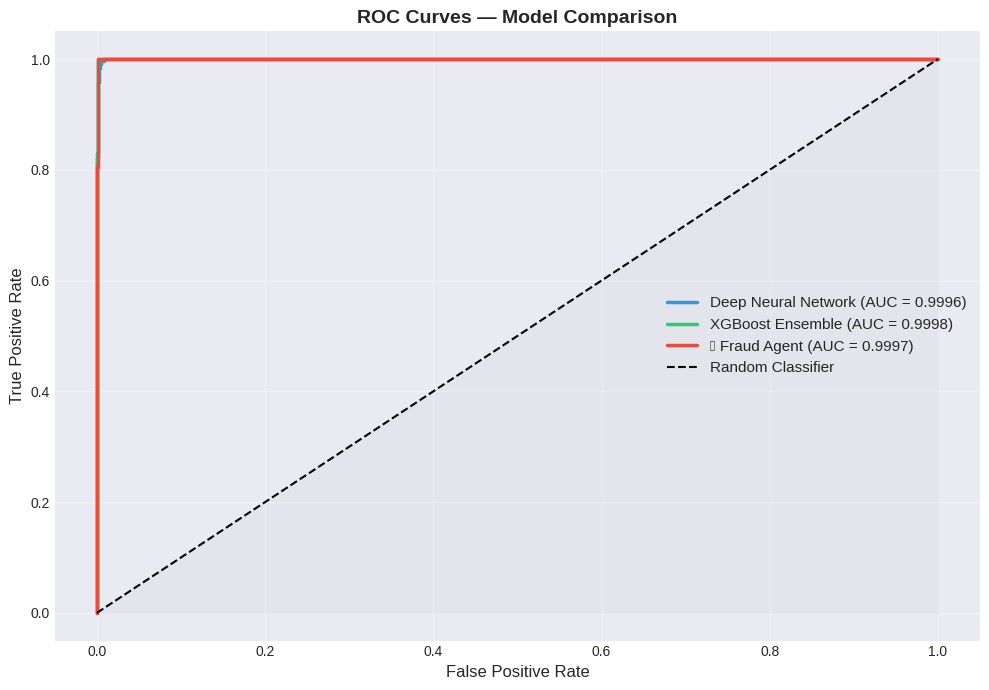

📊 Plot 9: ROC curves saved!


In [21]:
# ── PLOT 9: ROC Curves Comparison ──
plt.figure(figsize=(10, 7))

for pred, proba, name, color in models_info:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})',
             linewidth=2.5, color=color)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')
plt.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
plt.title('ROC Curves — Model Comparison', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('plot9_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Plot 9: ROC curves saved!")



📊 COMPLETE RESULTS TABLE
                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
   Deep Neural Network   0.99450   0.992530  0.9965  0.994511 0.999650
      XGBoost Ensemble   0.99875   0.997506  1.0000  0.998752 0.999784
Fraud Agent (Combined)   0.99825   0.996512  1.0000  0.998253 0.999741


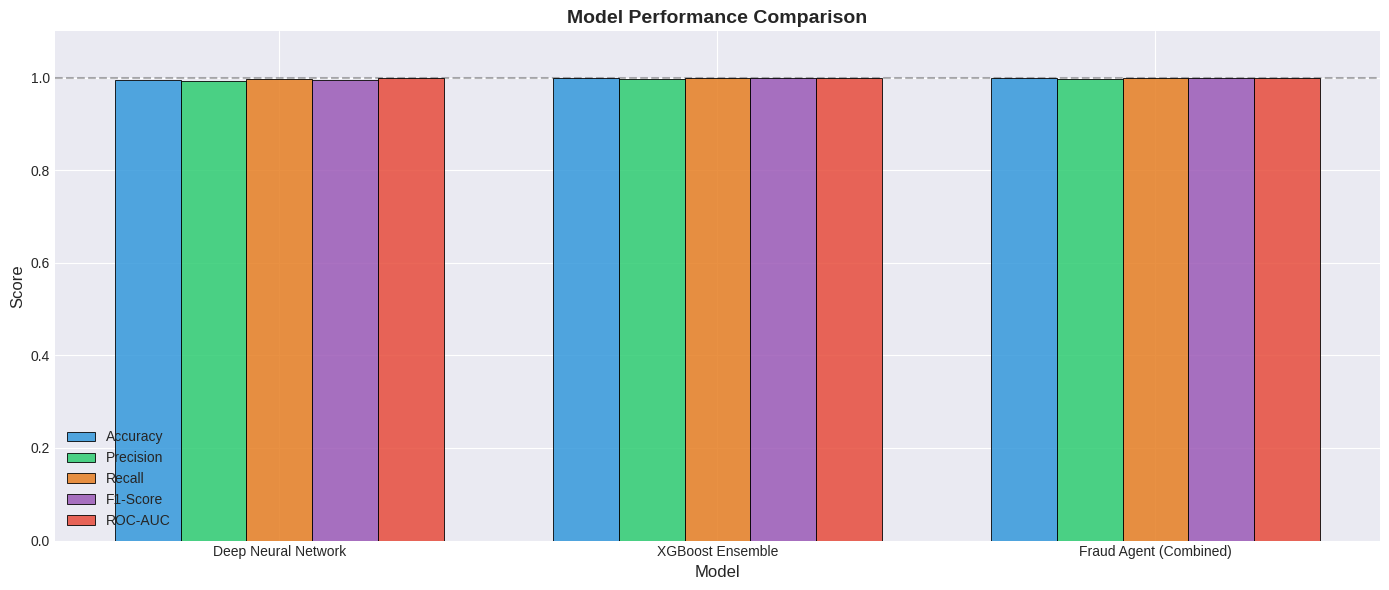


📊 Plot 10: Model comparison saved!


In [22]:
# ── PLOT 10: Model Performance Bar Chart ──
metrics_data = {
    'Model': ['Deep Neural Network', 'XGBoost Ensemble', 'Fraud Agent (Combined)'],
    'Accuracy':  [accuracy_score(y_test, dnn_pred),
                  accuracy_score(y_test, xgb_pred),
                  accuracy_score(y_test, agent_pred)],
    'Precision': [precision_score(y_test, dnn_pred),
                  precision_score(y_test, xgb_pred),
                  precision_score(y_test, agent_pred)],
    'Recall':    [recall_score(y_test, dnn_pred),
                  recall_score(y_test, xgb_pred),
                  recall_score(y_test, agent_pred)],
    'F1-Score':  [f1_score(y_test, dnn_pred),
                  f1_score(y_test, xgb_pred),
                  f1_score(y_test, agent_pred)],
    'ROC-AUC':   [roc_auc_score(y_test, dnn_proba),
                  roc_auc_score(y_test, xgb_proba),
                  roc_auc_score(y_test, agent_proba)],
}
results_df = pd.DataFrame(metrics_data)
print("\n📊 COMPLETE RESULTS TABLE")
print(results_df.to_string(index=False))

# Bar Chart
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(results_df['Model']))
width = 0.15
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
colors_m = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6', '#e74c3c']

for i, (metric, color) in enumerate(zip(metric_cols, colors_m)):
    bars = ax.bar(x + i*width, results_df[metric], width,
                  label=metric, color=color, alpha=0.85, edgecolor='black', linewidth=0.7)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width*2)
ax.set_xticklabels(results_df['Model'], fontsize=10)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.1)
ax.axhline(y=1.0, color='black', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('plot10_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📊 Plot 10: Model comparison saved!")


In [23]:
# ── DEMO: Agent Predicting on New Transactions ──
print("=" * 60)
print("🤖 FRAUD DETECTION AGENT — LIVE DEMO")
print("=" * 60)

# Sample 5 test transactions
sample_indices = np.random.choice(len(X_test), 5, replace=False)
sample_X = X_test.iloc[sample_indices]
sample_y = y_test.iloc[sample_indices]

sample_dnn   = dnn_model.predict(sample_X).flatten()
sample_xgb   = xgb_model.predict_proba(sample_X)[:, 1]
sample_agent = (0.4 * sample_dnn) + (0.6 * sample_xgb)
sample_pred  = (sample_agent >= 0.5).astype(int)

for i in range(5):
    actual = "🚨 FRAUD" if sample_y.iloc[i] == 1 else "✅ LEGIT"
    predict = "🚨 FRAUD" if sample_pred[i] == 1 else "✅ LEGIT"
    correct = "✓" if sample_y.iloc[i] == sample_pred[i] else "✗"
    print(f"Transaction {i+1}: Actual={actual} | Agent={predict} | Confidence={sample_agent[i]:.2%} [{correct}]")


🤖 FRAUD DETECTION AGENT — LIVE DEMO
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 619ms/step
Transaction 1: Actual=🚨 FRAUD | Agent=🚨 FRAUD | Confidence=99.43% [✓]
Transaction 2: Actual=🚨 FRAUD | Agent=🚨 FRAUD | Confidence=99.98% [✓]
Transaction 3: Actual=✅ LEGIT | Agent=✅ LEGIT | Confidence=0.29% [✓]
Transaction 4: Actual=✅ LEGIT | Agent=✅ LEGIT | Confidence=0.04% [✓]
Transaction 5: Actual=🚨 FRAUD | Agent=🚨 FRAUD | Confidence=99.91% [✓]
